# Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("darkgrid")
pd.set_option("display.max_columns", 30)

##  Load Data

In [2]:
df = pd.read_excel("../data/E Commerce Dataset.xlsx", sheet_name="E Comm")
print(df.shape)
df.head()

(5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [4]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


## Class Distribution

       count  Percentage
Churn                   
0       4682    0.831616
1        948    0.168384


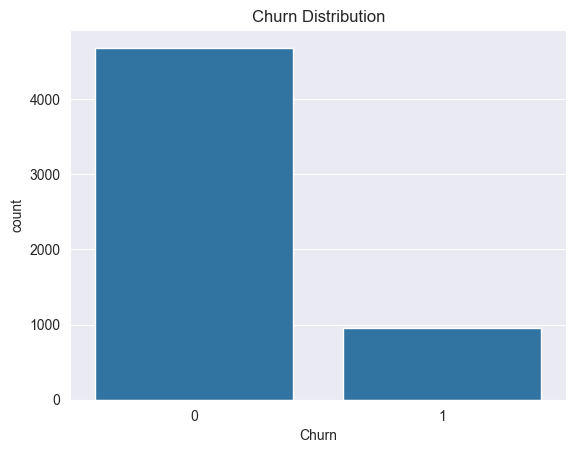

In [5]:
churns = pd.DataFrame(df.Churn.value_counts())
churns["Percentage"] = churns["count"] / churns["count"].sum()
print(churns)

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

~16.8% churn rate. The dataset is imbalanced. Accuracy is not a useful metric in this case.

## Missing Values

DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
dtype: int64


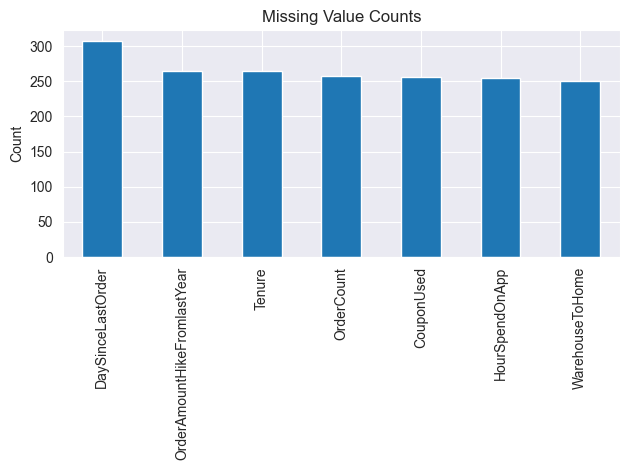

In [6]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)


missing.plot(kind="bar")
plt.title("Missing Value Counts")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

All missing columns are numerical. Patterns were assessed as **MAR (Missing At Random)** — no systematic link to the target was found. Median imputation is applied in the pipeline.

## Categorical Features

In [17]:
def stack_plot(data, group, target):
    _, ax = plt.subplots(figsize=(4, 3))
    df_ = (
        (data.groupby([group, target]).size() / data.groupby(group)[target].count())
        .reset_index()
        .pivot(columns=target, index=group, values=0)
    )
    df_.plot(kind="bar", stacked=True, ax=ax, color=["seagreen", "crimson"])
    ax.xaxis.set_tick_params(rotation=45)
    ax.set_xlabel(group)
    ax.set_ylabel("Churn Percentage")

In [ ]:
# Fixing duplicate labels before plotting
df.PreferredLoginDevice = df.PreferredLoginDevice.replace({"Mobile Phone": "Phone"})
df.PreferredPaymentMode = df.PreferredPaymentMode.replace(
    {"Cash on Delivery": "COD", "CC": "Credit Card"}
)
df.PreferedOrderCat = df.PreferedOrderCat.replace({"Mobile Phone": "Mobile"})

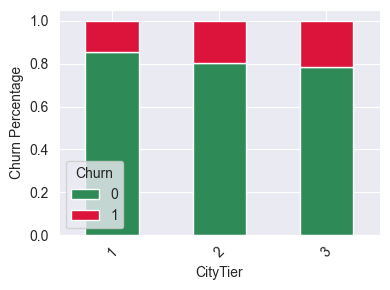

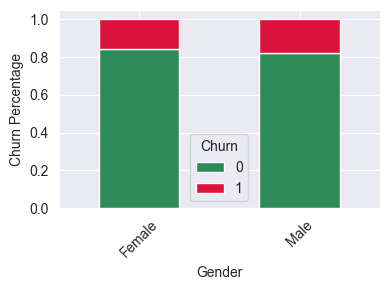

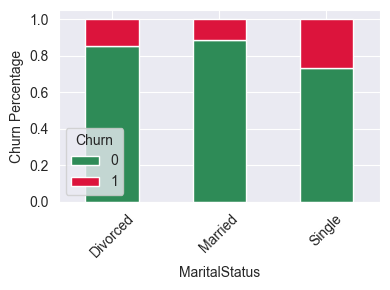

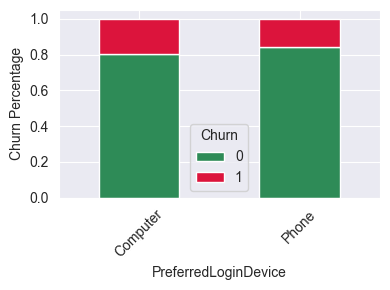

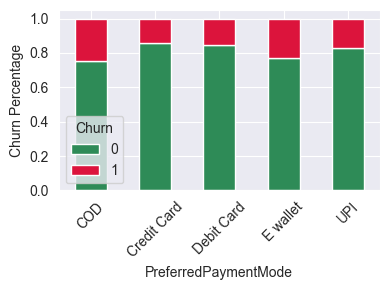

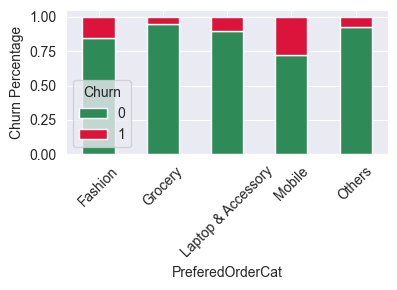

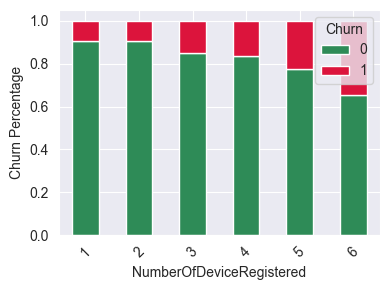

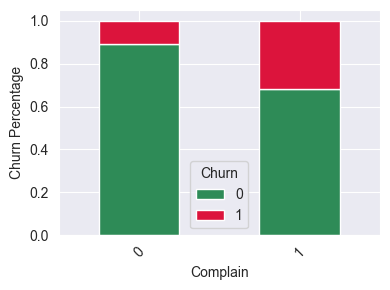

In [18]:
for col in [
    "CityTier",
    "Gender",
    "MaritalStatus",
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "PreferedOrderCat",
    "NumberOfDeviceRegistered",
    "Complain",
]:
    stack_plot(df, col, "Churn")
    plt.tight_layout()
    plt.show()

Observations:
- Single customers churn at 3 times the rate of married customers.
- Tier 1 cities show lowest churn.
- Grocery buyers are most loyal. Fashion and Mobile buyers churn the most.
- Customers with an active complaint last month churn at 31.7% vs 10.9% for non-complainers.

## Numerical Features

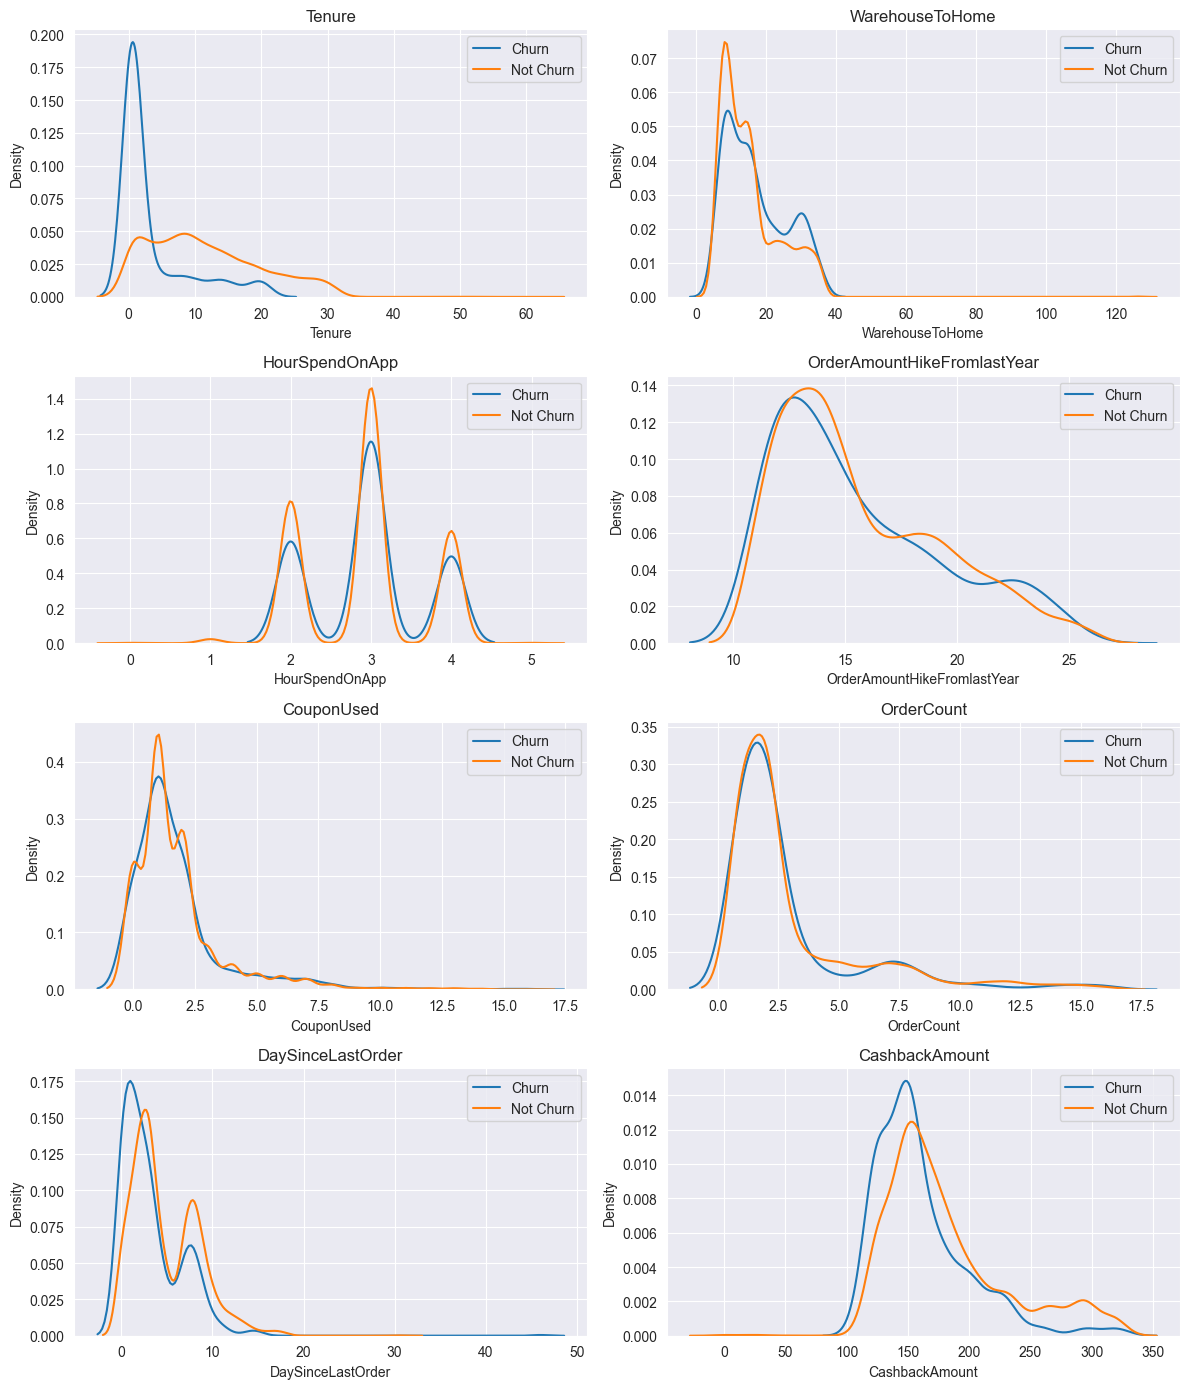

In [19]:
churn = df[df.Churn == 1]
no_churn = df[df.Churn == 0]

numerical_cols = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
]

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
for ax, col in zip(axes.flatten(), numerical_cols):
    sns.kdeplot(churn[col].dropna(), label="Churn", ax=ax)
    sns.kdeplot(no_churn[col].dropna(), label="Not Churn", ax=ax)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## Exploring Tenure

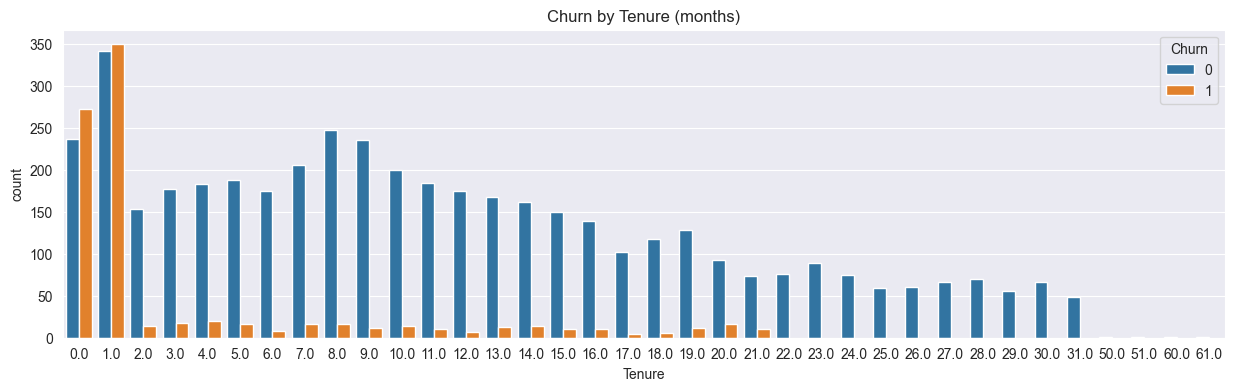

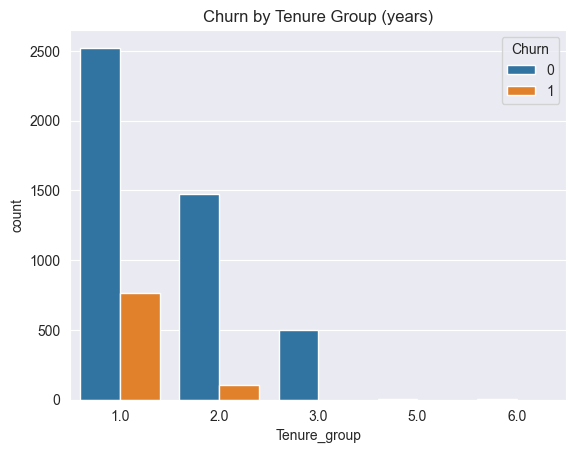

In [20]:
plt.figure(figsize=(15, 4))
sns.countplot(x="Tenure", hue="Churn", data=df)
plt.title("Churn by Tenure (months)")
plt.show()

# Converting Tenure from months to years
df["Tenure_group"] = df.Tenure.apply(lambda x: (x // 12) + 1 if pd.notna(x) else np.nan)
sns.countplot(x="Tenure_group", hue="Churn", data=df)
plt.title("Churn by Tenure Group (years)")
plt.show()

Most churn happens in year 1. This is the critical window. After 2 years, the survival curve almost flattens.